In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()  # Choose the kaggle.json file from your computer

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"darshikapremaranjan","key":"f4a10730b4a74a7c059ef8211fc398cd"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d sachinpatel21/az-handwritten-alphabets-in-csv-format

Dataset URL: https://www.kaggle.com/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format
License(s): CC0-1.0
 93% 172M/185M [00:00<00:00, 217MB/s]
100% 185M/185M [00:00<00:00, 206MB/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip  az-handwritten-alphabets-in-csv-format.zip -d '/content/drive/MyDrive/compuervision'


Archive:  az-handwritten-alphabets-in-csv-format.zip
replace /content/drive/MyDrive/compuervision/A_Z Handwritten Data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/compuervision/A_Z Handwritten Data/A_Z Handwritten Data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [2]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import ZeroPadding2D
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import add
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
import matplotlib
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import SGD
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
from imutils.contours import sort_contours
from imutils import build_montages
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from tensorflow.keras.datasets import mnist
import numpy as np

In [3]:
def load_az_dataset(datasetPath):
    """
    Load the A-Z handwritten alphabet dataset.

    Args:
        datasetPath (str): Path to the A-Z dataset file, where each row consists of a label and pixel values.

    Returns:
        tuple: A 2-tuple of (data, labels) where:
            - data (np.array): Array of images with shape (num_samples, 28, 28).
            - labels (np.array): Array of integer labels corresponding to the images.
    """
    data = []
    labels = []

    for row in open(datasetPath):
        row = row.split(",")
        label = int(row[0])
        image = np.array([int(x) for x in row[1:]], dtype="uint8")

        image = image.reshape((28, 28))

        data.append(image)
        labels.append(label)

    data = np.array(data, dtype="float32")
    labels = np.array(labels, dtype="int")

    return (data, labels)

In [4]:
def load_mnist_dataset():
    """
    Load the MNIST handwritten digit dataset.

    Returns:
        tuple: A 2-tuple of (data, labels) where:
            - data (np.array): Combined array of images from training and testing datasets with shape (num_samples, 28, 28).
            - labels (np.array): Combined array of integer labels corresponding to the images.
    """
    ((trainData, trainLabels), (testData, testLabels)) = mnist.load_data()
    data = np.vstack([trainData, testData])
    labels = np.hstack([trainLabels, testLabels])

    return (data, labels)

In [5]:
from tensorflow.keras.layers import BatchNormalization, Activation, Conv2D, add, Input, AveragePooling2D, Flatten, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

class ResNet:
    @staticmethod
    def residual_module(data, K, stride, chanDim, red=False, reg=0.0001, bnEps=2e-5, bnMom=0.9):
        shortcut = data
        bn1 = BatchNormalization(axis=chanDim, epsilon=bnEps, momentum=bnMom)(data)
        act1 = Activation("relu")(bn1)
        conv1 = Conv2D(int(K * 0.25), (1, 1), use_bias=False, kernel_regularizer=l2(reg))(act1)
        bn2 = BatchNormalization(axis=chanDim, epsilon=bnEps, momentum=bnMom)(conv1)
        act2 = Activation("relu")(bn2)
        conv2 = Conv2D(int(K * 0.25), (3, 3), strides=stride, padding="same", use_bias=False, kernel_regularizer=l2(reg))(act2)
        bn3 = BatchNormalization(axis=chanDim, epsilon=bnEps, momentum=bnMom)(conv2)
        act3 = Activation("relu")(bn3)
        conv3 = Conv2D(K, (1, 1), use_bias=False, kernel_regularizer=l2(reg))(act3)
        if red:
            shortcut = Conv2D(K, (1, 1), strides=stride, use_bias=False, kernel_regularizer=l2(reg))(act1)
        x = add([conv3, shortcut])
        return x

    @staticmethod
    def build(width, height, depth, classes, stages, filters, reg=0.0001, bnEps=2e-5, bnMom=0.9, dataset="cifar"):
        inputShape = (height, width, depth)
        chanDim = -1
        if K.image_data_format() == "channels_first":
            inputShape = (depth, height, width)
            chanDim = 1
        inputs = Input(shape=inputShape)
        x = BatchNormalization(axis=chanDim, epsilon=bnEps, momentum=bnMom)(inputs)
        x = Conv2D(filters[0], (3, 3), use_bias=False, padding="same", kernel_regularizer=l2(reg))(x)
        for i in range(0, len(stages)):
            stride = (1, 1) if i == 0 else (2, 2)
            x = ResNet.residual_module(x, filters[i + 1], stride, chanDim, red=True, bnEps=bnEps, bnMom=bnMom)
            for j in range(0, stages[i] - 1):
                x = ResNet.residual_module(x, filters[i + 1], (1, 1), chanDim, bnEps=bnEps, bnMom=bnMom)
        x = BatchNormalization(axis=chanDim, epsilon=bnEps, momentum=bnMom)(x)
        x = Activation("relu")(x)
        x = AveragePooling2D((8, 8))(x)
        x = Flatten()(x)
        x = Dense(classes, kernel_regularizer=l2(reg))(x)
        x = Activation("softmax")(x)
        model = Model(inputs, x, name="resnet")
        return model


In [10]:
# Load the A-Z handwritten dataset
(az_images, az_labels) = load_az_dataset('/content/drive/MyDrive/compuervision/A_Z Handwritten Data/A_Z Handwritten Data.csv')

# Load the MNIST dataset
(digit_images, digit_labels) = load_mnist_dataset()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
"""
This code preprocesses the combined A-Z and MNIST datasets for training a machine learning model:
1. Adjusts A-Z character labels to avoid overlap with MNIST digit labels.
2. Combines the datasets by stacking the image data and labels.
3. Resizes all images to 32x32 pixels to match the input requirements of the model.
4. Adds a channel dimension and normalizes pixel intensities to [0, 1].
5. Converts integer labels to one-hot encoded vectors for classification.
6. Computes class weights to address class imbalance in the combined dataset.
"""
az_labels += 10

# Combine the A-Z and MNIST datasets
images = np.vstack([az_images, digit_images])
labels = np.hstack([az_labels, digit_labels])

# Resize images to 32x32 pixels as required by the architecture
images = [cv2.resize(image, (32, 32)) for image in images]
images = np.array(images, dtype="float32")

# Add a channel dimension to every image and normalize pixel intensities
images = np.expand_dims(images, axis=-1)
images /= 255.0

# Convert the labels from integers to one-hot encoded vectors
label_encoder = LabelBinarizer()
labels = label_encoder.fit_transform(labels)

# Compute the class weights to address class imbalance
class_totals = labels.sum(axis=0)
class_weights = {i: class_totals.max() / class_totals[i] for i in range(len(class_totals))}


In [12]:
"""
 the dataset into training and testing splits.
"""
(train_images, test_images, train_labels, test_labels) = train_test_split(
    images, labels, test_size=0.20, stratify=labels, random_state=42
)


In [13]:
# construct the image generator for data augmentation
image_augmenter = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.05,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=False,
    fill_mode="nearest"
)

In [14]:
#initialize the number of epochs to train for, initial learning rate,
from tensorflow.keras.optimizers import SGD
EPOCHS = 50
INITIAL_LR = 1e-1
BATCH_SIZE = 128


In [15]:
optimizer = SGD(learning_rate=INITIAL_LR, momentum=0.9, decay=INITIAL_LR / EPOCHS, nesterov=True)
resnet_model = ResNet.build(
    width=32, height=32, depth=1, classes=len(label_encoder.classes_),
    stages=(3, 3, 3), filters=(64, 64, 128, 256), reg=0.0005
)


/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [16]:
#compile the model
resnet_model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [17]:
history = resnet_model.fit(
    image_augmenter.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    validation_data=(test_images, test_labels),
    steps_per_epoch=len(train_images) // BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2765/2765 ━━━━━━━━━━━━━━━━━━━━ 256s 83ms/step - accuracy: 0.7764 - loss: 3.7094 - val_accuracy: 0.8578 - val_loss: 0.9474
Epoch 2/50
   1/2765 ━━━━━━━━━━━━━━━━━━━━ 2:46 60ms/step - accuracy: 0.9062 - loss: 1.6161

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


2765/2765 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9062 - loss: 1.6161 - val_accuracy: 0.8680 - val_loss: 0.9238
Epoch 3/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 211s 76ms/step - accuracy: 0.9058 - loss: 1.4577 - val_accuracy: 0.9109 - val_loss: 0.7846
Epoch 4/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9297 - loss: 1.2259 - val_accuracy: 0.9028 - val_loss: 0.8018
Epoch 5/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 251s 77ms/step - accuracy: 0.9125 - loss: 1.3776 - val_accuracy: 0.8599 - val_loss: 0.8996
Epoch 6/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9531 - loss: 1.4036 - val_accuracy: 0.8685 - val_loss: 0.8781
Epoch 7/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 204s 74ms/step - accuracy: 0.9196 - loss: 1.3124 - val_accuracy: 0.8689 - val_loss: 0.8665
Epoch 8/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9062 - loss: 1.0850 - val_accuracy: 0.8690 - val_loss: 0.8642
Epoch 9/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 248s 73ms/step - accuracy: 0.9210 - loss: 1.27

[INFO] Evaluating the network...
692/692 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step


              precision    recall  f1-score   support

           0       0.26      0.75      0.39      1381
           1       0.99      0.92      0.96      1575
           2       0.94      0.89      0.91      1398
           3       0.98      0.98      0.98      1428
           4       0.84      0.96      0.90      1365
           5       0.72      0.91      0.81      1263
           6       0.96      0.93      0.94      1375
           7       0.92      0.99      0.95      1459
           8       0.92      0.99      0.95      1365
           9       0.98      0.98      0.98      1392
           A       0.99      0.99      0.99      2774
           B       0.97      0.97      0.97      1734
           C       0.99      0.98      0.98      4682
           D       0.96      0.92      0.94      2027
           E       0.97      0.99      0.98      2288
           F       0.91      0.99      0.95       232
           G       0.81      0.97      0.88      1152
           H       0.97    

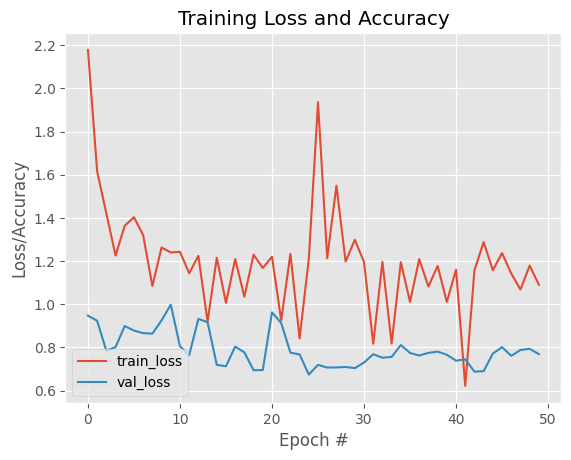

In [18]:
"""
Define label names, evaluate the trained model, save the model to disk,
and plot the training history for loss and accuracy.
"""
# Define the list of label names (digits + A-Z characters)
label_names = "0123456789"
label_names += "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
label_names = [label for label in label_names]

model_predictions = resnet_model.predict(test_images, batch_size=BATCH_SIZE)
print(classification_report(
    test_labels.argmax(axis=1),
    model_predictions.argmax(axis=1),
    target_names=label_names
))

resnet_model.save("handwriting_model.h5")
# Plot and save the training history
epochs_range = np.arange(0, EPOCHS)
plt.style.use("ggplot")
plt.figure()
plt.plot(epochs_range, history.history["loss"], label="train_loss")
plt.plot(epochs_range, history.history["val_loss"], label="val_loss")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig("plot")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━

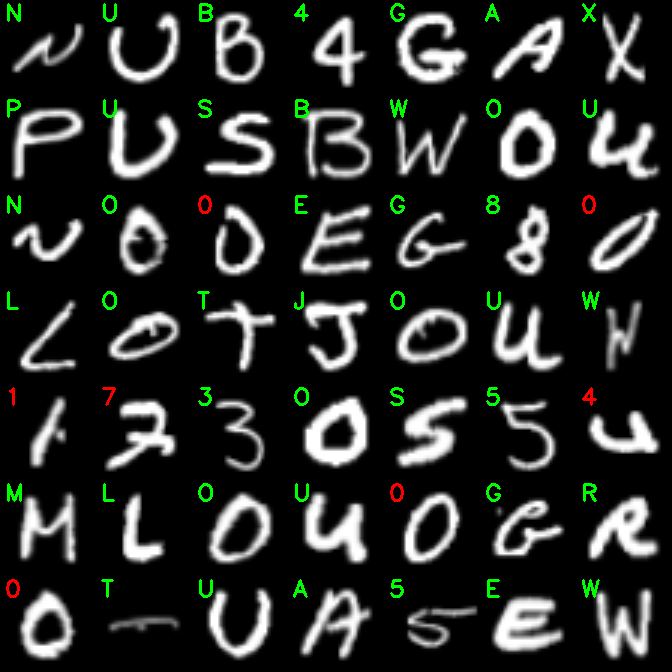

-1

In [19]:
"""
Randomly select a few testing characters, classify them, and create a montage of the predicted results.
Correct predictions are marked in green, and incorrect predictions are marked in red.
The images are resized and displayed in a montage for better visualization.
"""
#initialize the list of output images
output_images = []

# Randomly select a few testing characters
for i in np.random.choice(np.arange(0, len(test_labels)), size=(49,)):
    # Classify the character
    probabilities = resnet_model.predict(test_images[np.newaxis, i])
    prediction = probabilities.argmax(axis=1)
    label = label_names[prediction[0]]

    # Extract the image from the test data and initialize the label color as green (correct)
    image = (test_images[i] * 255).astype("uint8")
    label_color = (0, 255, 0)

    # If the prediction is incorrect, change the label color to red
    if prediction[0] != np.argmax(test_labels[i]):
        label_color = (0, 0, 255)

    # Merge the channels into one image, resize from 32x32 to 96x96 for better visibility
    image = cv2.merge([image] * 3)
    image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)

    # Draw the predicted label on the image
    cv2.putText(image, label, (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.75,
                label_color, 2)

    # Add the image to the list of output images
    output_images.append(image)

# Construct the montage for the images
montage = build_montages(output_images, (96, 96), (7, 7))[0]

# Display the output montage
cv2_imshow(montage)
cv2.waitKey(0)
